<h1 style="text-align: center;">SMT Challenge 2025 Jump Expected Model</h1>
<h3 style="text-align: center;"><i>Team 15</i> - this notebook is used to develop the model that will model the expected reaction, burst, and route components of Jump</h3>

### Necessary Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
scaler = StandardScaler()
from sklearn.metrics import root_mean_squared_error

np.random.seed(42)

pd.set_option('display.max_columns', None)

### Loading in the Data

In [2]:
jump_df = pd.read_csv('data_w_aggression.csv').iloc[:, 1:].copy()
## we're going to have separate models for each metric and for each outfield pos (totaling 9 different models)
## makes sure that metric doesn't have null values
jump_reaction_df = jump_df[~jump_df['reaction'].isna()].reset_index(drop=True).copy()
jump_burst_df = jump_df[~jump_df['burst'].isna()].reset_index(drop=True).copy()
jump_route_df = jump_df[~jump_df['route'].isna()].reset_index(drop=True).copy()

### Helper Functions

In [3]:
def jump_model(df: pd.DataFrame, component: str, position: int):
    """
    Returns the eNET model for that Jump component for that positon
    Makes it easier to do the average baseline for all 9 (3 positions x 3 components) models
    
    Arguments: df: Dataframe, component: one of Jump's components (reaction, burst, route), position: outfield position code (7, 8, or 9)
    """
    df = df.copy()
    df = df[df['player_attempt'] == position].reset_index(drop=True).copy()
    
    ## prepares the features of each model
    X = df[['opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle', 'difficulty_level']].copy()
    X.loc[:, 'direction_cat_code'] = X['direction_angle'].astype('category').cat.codes
    X.loc[:, 'difficulty_cat_code'] = X['difficulty_level'].astype('category').cat.codes
    X_scaled = scaler.fit_transform(X[['opportunity_time', 'distance_needed', 'distance_to_wall']].values)
    X = np.hstack([X_scaled, X[['direction_cat_code', 'difficulty_cat_code']].values])
    y = df[component].values

    rmse_scores = []
    best_rmse = np.inf
    best_model = None

    param_grid = {'alpha': [0.01, 0.1, 1, 10], 
                  'l1_ratio': [0.1, 0.5, 0.9]
                  }
    
    ## validates the model using 10-fold validation with 5 repetitions
    cv = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        ## used for the param tuning
        param_cv = KFold(n_splits=5, shuffle=True, random_state=42)

        model = ElasticNet()
        model_grid = GridSearchCV(model, param_grid, scoring='neg_root_mean_squared_error', cv=param_cv)
        model_grid.fit(X_train, y_train)

        y_pred = model_grid.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        rmse_scores.append(rmse)

        ## best eNET is the one with the lowest rmse
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model_grid.best_estimator_

    return best_model, best_rmse

## Reaction Model

### Left Fielder

#### EDA

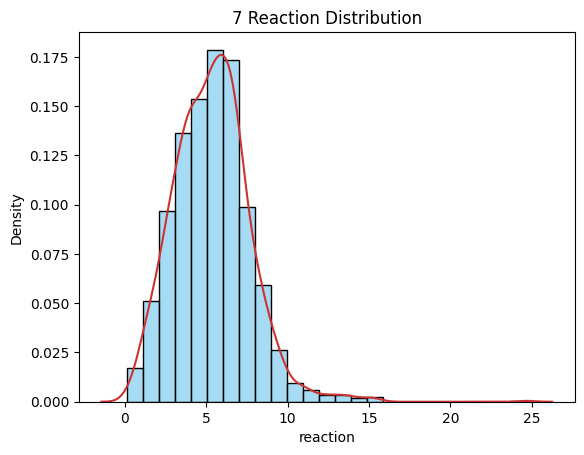

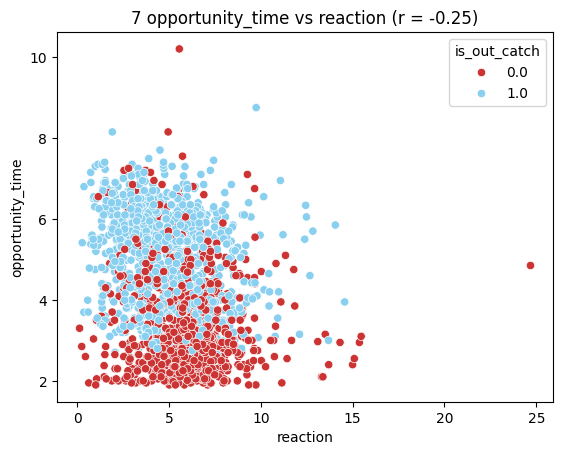

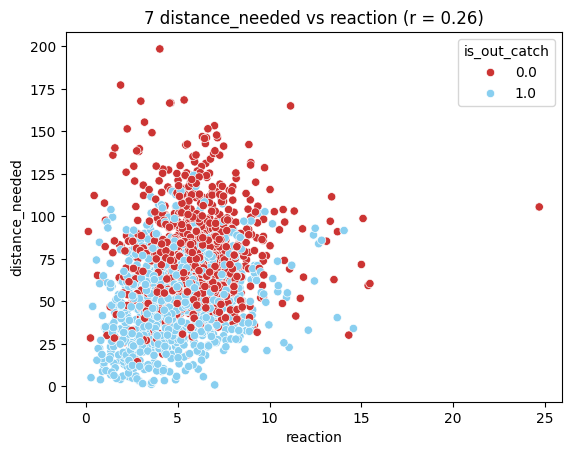

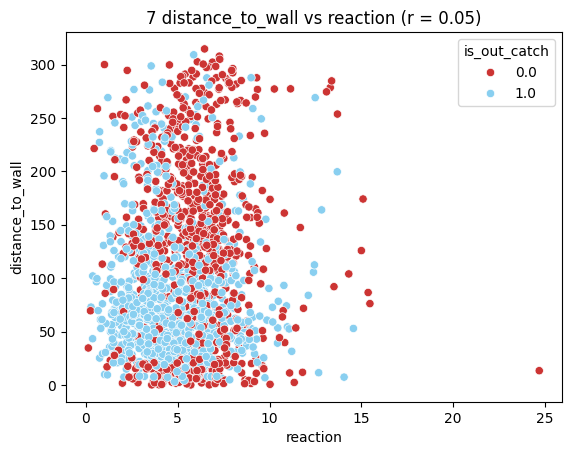

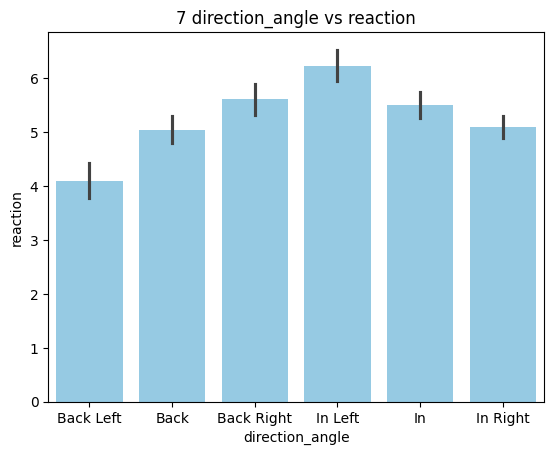

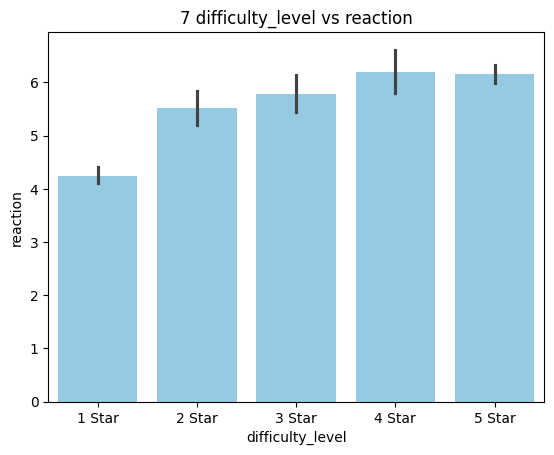

In [ ]:
lf_jump_reaction = jump_reaction_df[jump_reaction_df['player_attempt'] == 7].reset_index(drop=True).copy()

of_pos = 7

plt.figure()
sns.histplot(data=lf_jump_reaction, x='reaction', color='#89CFF0', stat='density', bins=25)
sns.kdeplot(data=lf_jump_reaction, x='reaction', color='#CC3433')
plt.title(f'{of_pos} Reaction Distribution')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_reaction, x='reaction', y='opportunity_time', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_ot, p_ot = stats.pearsonr(lf_jump_reaction['opportunity_time'], lf_jump_reaction['reaction'])
plt.title(f'{of_pos} opportunity_time vs reaction (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_reaction, x='reaction', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dn, p_dn = stats.pearsonr(lf_jump_reaction['distance_needed'], lf_jump_reaction['reaction'])
plt.title(f'{of_pos} distance_needed vs reaction (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_reaction, x='reaction', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dw, p_dw = stats.pearsonr(lf_jump_reaction['distance_to_wall'], lf_jump_reaction['reaction'])
plt.title(f'{of_pos} distance_to_wall vs reaction (r = {round(r_dw, 2)})')
plt.show()

plt.figure()
ordered_directions = ['Back Left', 'Back', 'Back Right', 'In Left', 'In', 'In Right']
sns.barplot(data=lf_jump_reaction, x='direction_angle', y='reaction', order = ordered_directions, color='#89CFF0')
plt.title(f'{of_pos} direction_angle vs reaction')
plt.show()

plt.figure()
ordered_levels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']
sns.barplot(data=lf_jump_reaction, x='difficulty_level', y='reaction', order = ordered_levels, color='#89CFF0')
plt.title(f'{of_pos} difficulty_level vs reaction')
plt.show()

#### Modeling

In [426]:
## reaction model for left fielder
reaction_7_eNET = jump_model(jump_reaction_df, 'reaction', 7)
reaction_7_eNET

(ElasticNet(alpha=0.01, l1_ratio=0.1), 1.7379930375825743)

### Center Fielder

#### EDA

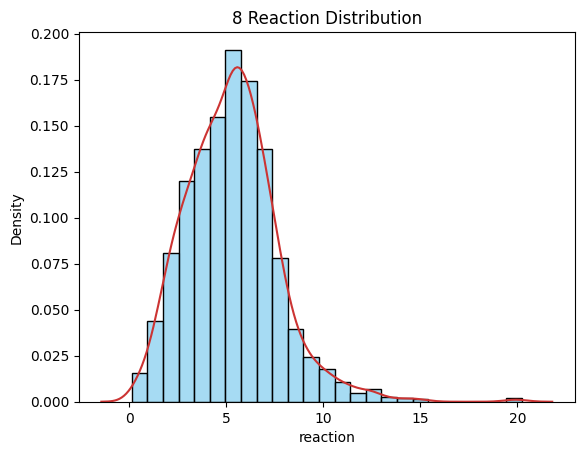

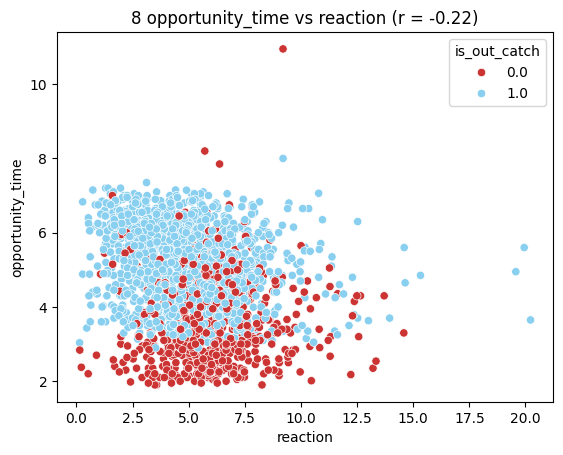

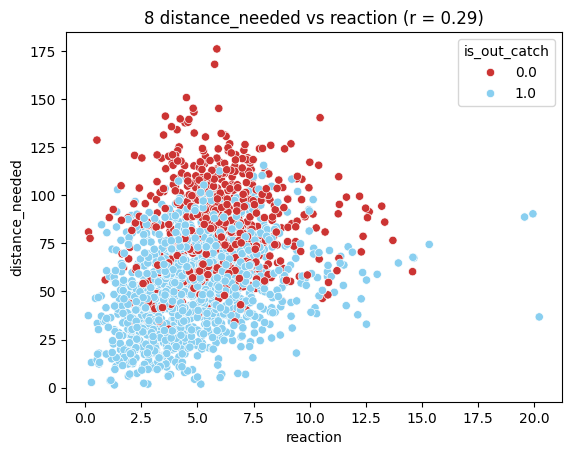

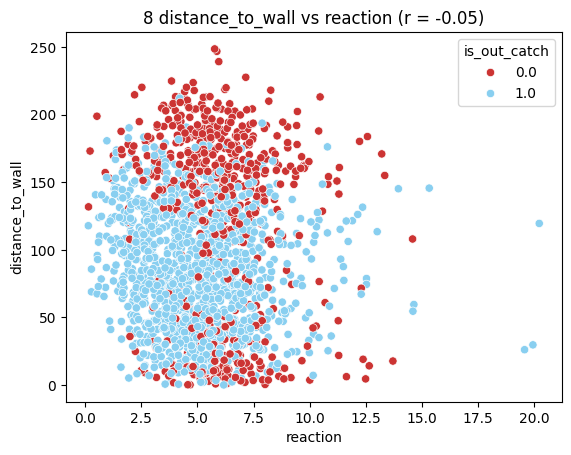

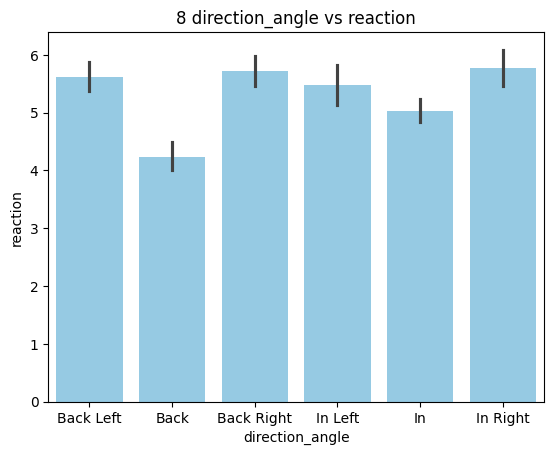

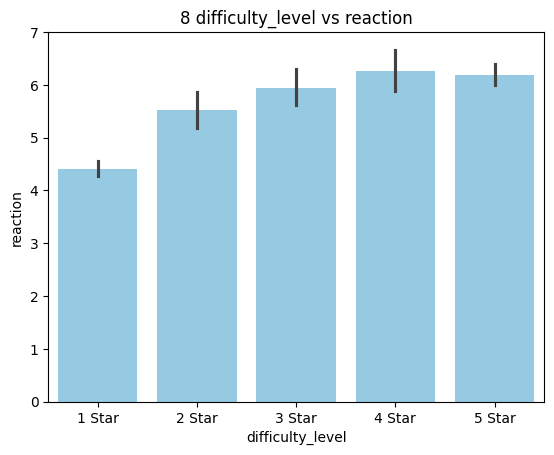

In [13]:
cf_jump_reaction = jump_reaction_df[jump_reaction_df['player_attempt'] == 8].reset_index(drop=True).copy()

of_pos = 8

plt.figure()
sns.histplot(data=cf_jump_reaction, x='reaction', color='#89CFF0', stat='density', bins=25)
sns.kdeplot(data=cf_jump_reaction, x='reaction', color='#CC3433')
plt.title(f'{of_pos} Reaction Distribution')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_reaction, x='reaction', y='opportunity_time', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_ot, p_ot = stats.pearsonr(cf_jump_reaction['opportunity_time'], cf_jump_reaction['reaction'])
plt.title(f'{of_pos} opportunity_time vs reaction (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_reaction, x='reaction', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dn, p_dn = stats.pearsonr(cf_jump_reaction['distance_needed'], cf_jump_reaction['reaction'])
plt.title(f'{of_pos} distance_needed vs reaction (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_reaction, x='reaction', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dw, p_dw = stats.pearsonr(cf_jump_reaction['distance_to_wall'], cf_jump_reaction['reaction'])
plt.title(f'{of_pos} distance_to_wall vs reaction (r = {round(r_dw, 2)})')
plt.show()

plt.figure()
ordered_directions = ['Back Left', 'Back', 'Back Right', 'In Left', 'In', 'In Right']
sns.barplot(data=cf_jump_reaction, x='direction_angle', y='reaction', order = ordered_directions, color='#89CFF0')
plt.title(f'{of_pos} direction_angle vs reaction')
plt.show()

plt.figure()
ordered_levels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']
sns.barplot(data=cf_jump_reaction, x='difficulty_level', y='reaction', order = ordered_levels, color='#89CFF0')
plt.title(f'{of_pos} difficulty_level vs reaction')
plt.show()

#### Modeling

In [427]:
## reaction model for center fielder
reaction_8_eNET = jump_model(jump_reaction_df, 'reaction', 8)
reaction_8_eNET

(ElasticNet(alpha=0.01, l1_ratio=0.1), 1.68626514636911)

### Right Fielder

#### EDA

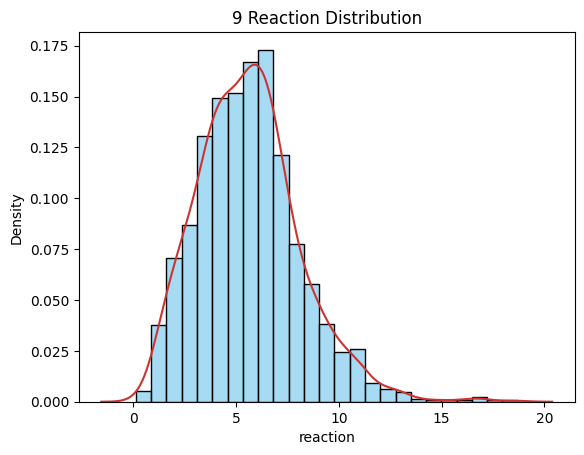

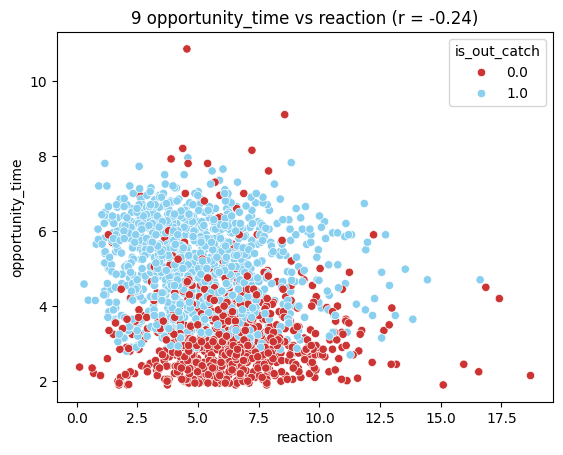

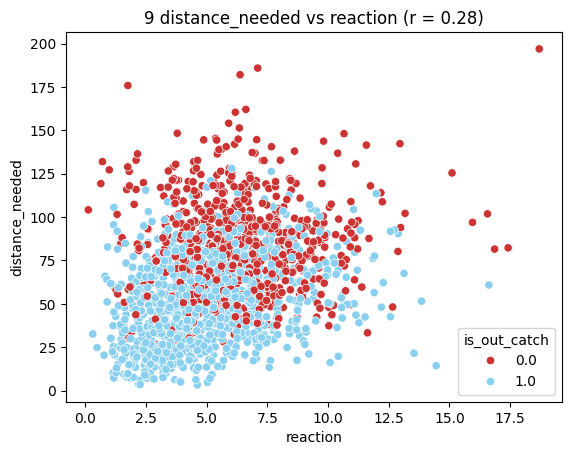

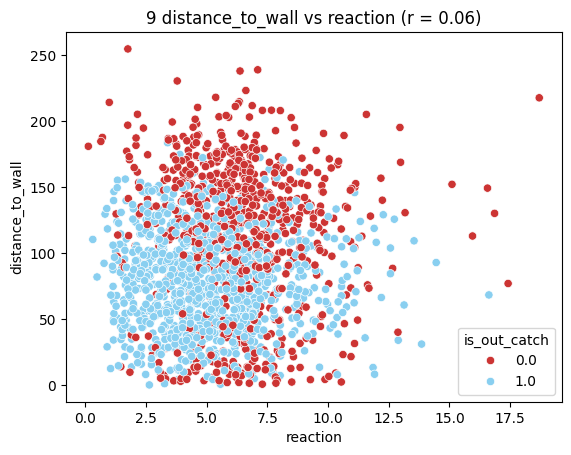

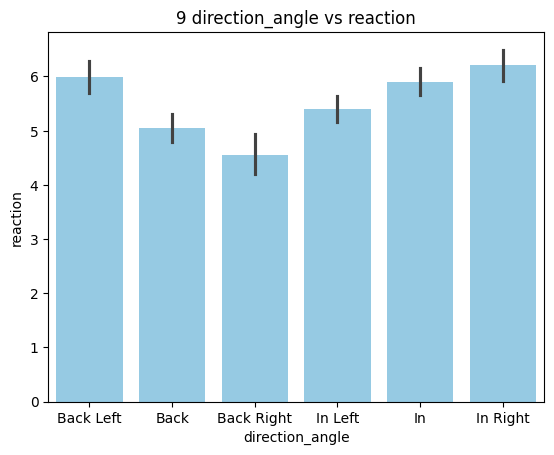

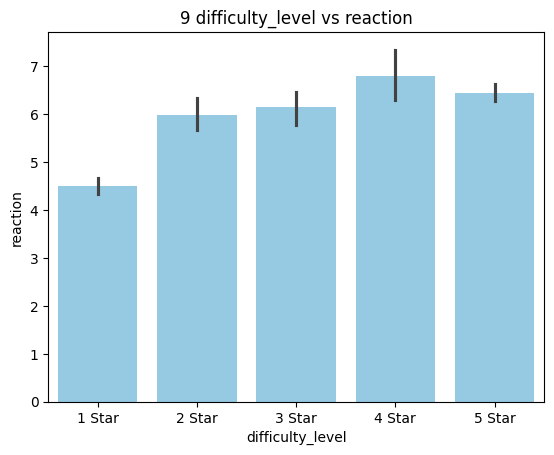

In [14]:
rf_jump_reaction = jump_reaction_df[jump_reaction_df['player_attempt'] == 9].reset_index(drop=True).copy()

of_pos = 9

plt.figure()
sns.histplot(data=rf_jump_reaction, x='reaction', color='#89CFF0', stat='density', bins=25)
sns.kdeplot(data=rf_jump_reaction, x='reaction', color='#CC3433')
plt.title(f'{of_pos} Reaction Distribution')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_reaction, x='reaction', y='opportunity_time', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_ot, p_ot = stats.pearsonr(rf_jump_reaction['opportunity_time'], rf_jump_reaction['reaction'])
plt.title(f'{of_pos} opportunity_time vs reaction (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_reaction, x='reaction', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dn, p_dn = stats.pearsonr(rf_jump_reaction['distance_needed'], rf_jump_reaction['reaction'])
plt.title(f'{of_pos} distance_needed vs reaction (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_reaction, x='reaction', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dw, p_dw = stats.pearsonr(rf_jump_reaction['distance_to_wall'], rf_jump_reaction['reaction'])
plt.title(f'{of_pos} distance_to_wall vs reaction (r = {round(r_dw, 2)})')
plt.show()

plt.figure()
ordered_directions = ['Back Left', 'Back', 'Back Right', 'In Left', 'In', 'In Right']
sns.barplot(data=rf_jump_reaction, x='direction_angle', y='reaction', order = ordered_directions, color='#89CFF0')
plt.title(f'{of_pos} direction_angle vs reaction')
plt.show()

plt.figure()
ordered_levels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']
sns.barplot(data=rf_jump_reaction, x='difficulty_level', y='reaction', order = ordered_levels, color='#89CFF0')
plt.title(f'{of_pos} difficulty_level vs reaction')
plt.show()

#### Modeling

In [4]:
## reaction model for right fielder
reaction_9_eNET = jump_model(jump_reaction_df, 'reaction', 9)
reaction_9_eNET

NameError: name 'KFold' is not defined

## Burst Model

### Left Fielder

#### EDA

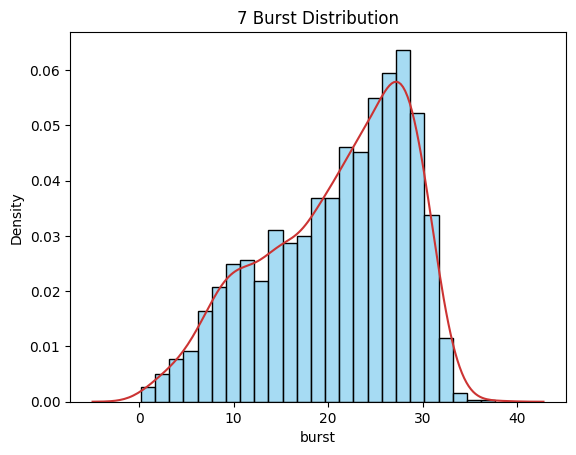

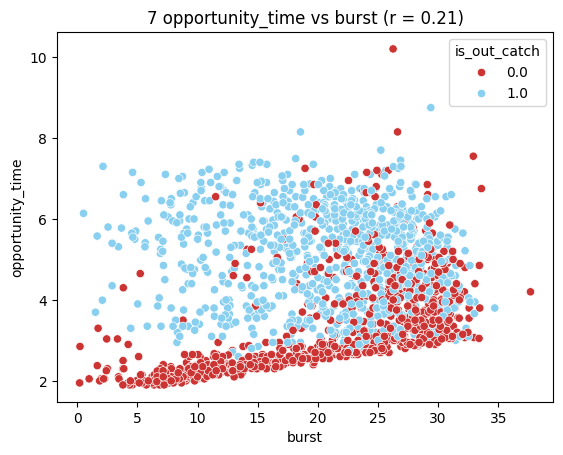

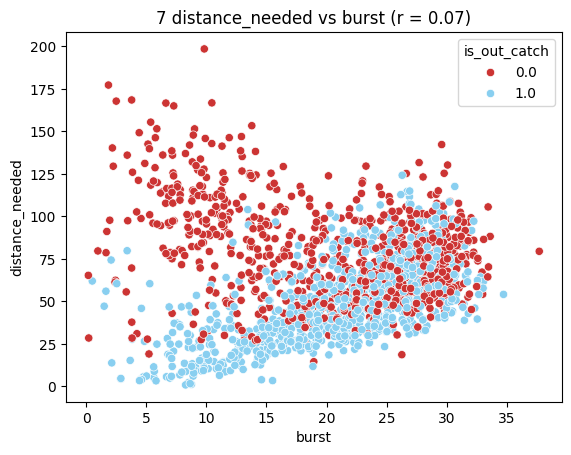

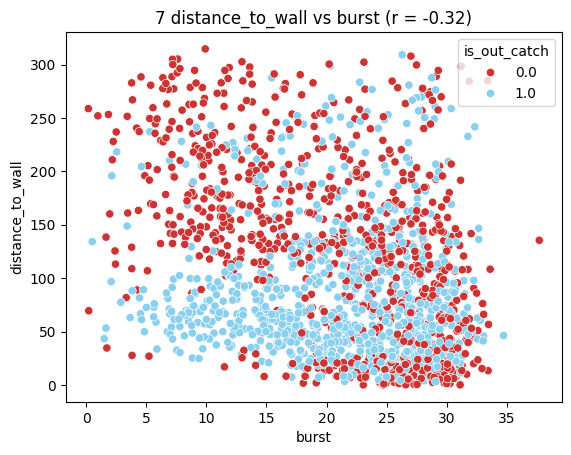

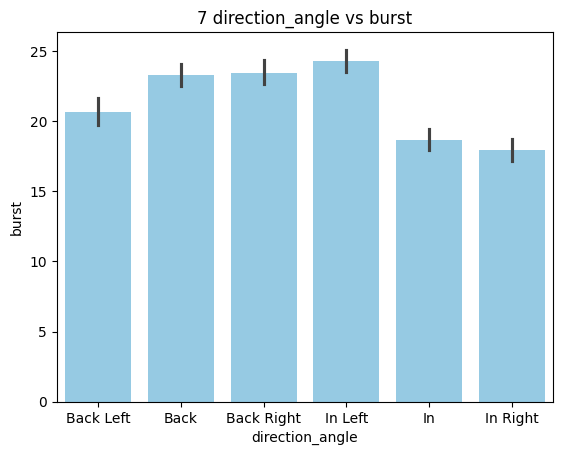

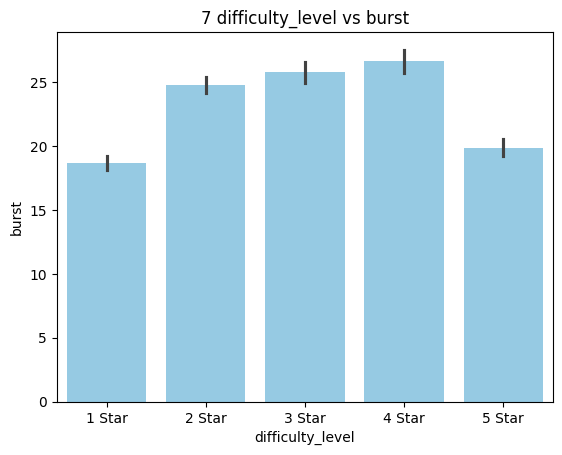

In [15]:
lf_jump_burst = jump_burst_df[jump_burst_df['player_attempt'] == 7].reset_index(drop=True).copy()

of_pos = 7

plt.figure()
sns.histplot(data=lf_jump_burst, x='burst', color='#89CFF0', stat='density', bins=25)
sns.kdeplot(data=lf_jump_burst, x='burst', color='#CC3433')
plt.title(f'{of_pos} Burst Distribution')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_burst, x='burst', y='opportunity_time', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_ot, p_ot = stats.pearsonr(lf_jump_burst['opportunity_time'], lf_jump_burst['burst'])
plt.title(f'{of_pos} opportunity_time vs burst (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_burst, x='burst', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dn, p_dn = stats.pearsonr(lf_jump_burst['distance_needed'], lf_jump_burst['burst'])
plt.title(f'{of_pos} distance_needed vs burst (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_burst, x='burst', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dw, p_dw = stats.pearsonr(lf_jump_burst['distance_to_wall'], lf_jump_burst['burst'])
plt.title(f'{of_pos} distance_to_wall vs burst (r = {round(r_dw, 2)})')
plt.show()

plt.figure()
ordered_directions = ['Back Left', 'Back', 'Back Right', 'In Left', 'In', 'In Right']
sns.barplot(data=lf_jump_burst, x='direction_angle', y='burst', order = ordered_directions, color='#89CFF0')
plt.title(f'{of_pos} direction_angle vs burst')
plt.show()

plt.figure()
ordered_levels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']
sns.barplot(data=lf_jump_burst, x='difficulty_level', y='burst', order = ordered_levels, color='#89CFF0')
plt.title(f'{of_pos} difficulty_level vs burst')
plt.show()

#### Modeling

In [429]:
## burst model for left fielder
burst_7_eNET = jump_model(jump_burst_df, 'burst', 7)
burst_7_eNET

(ElasticNet(alpha=0.01, l1_ratio=0.1), 5.910551708975415)

### Center Fielder

#### EDA

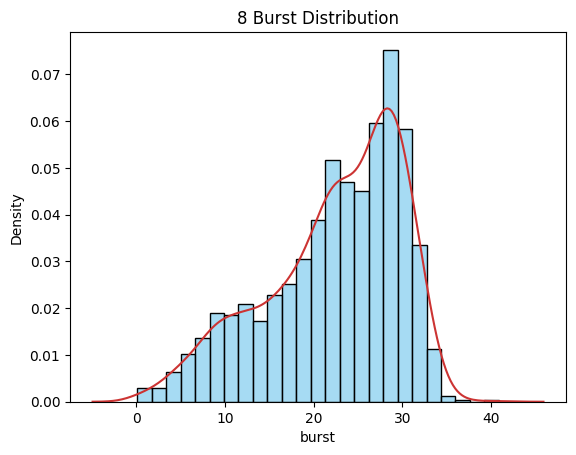

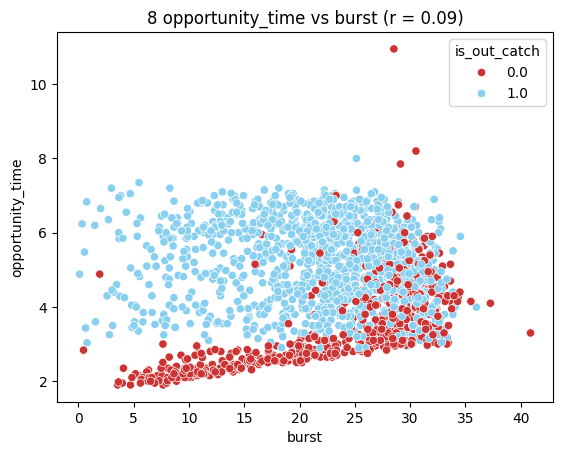

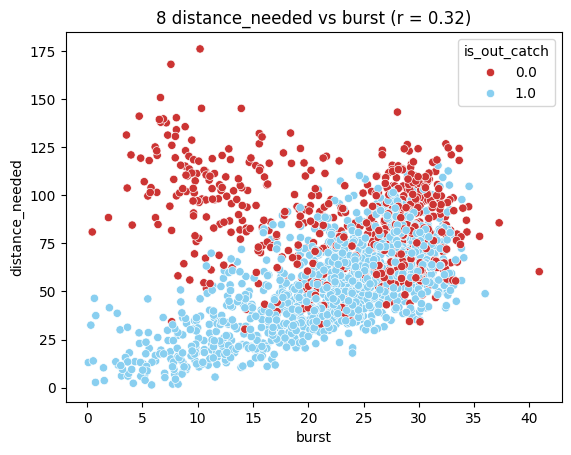

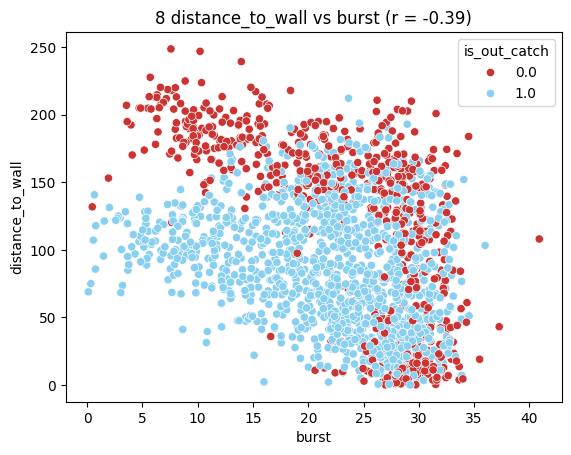

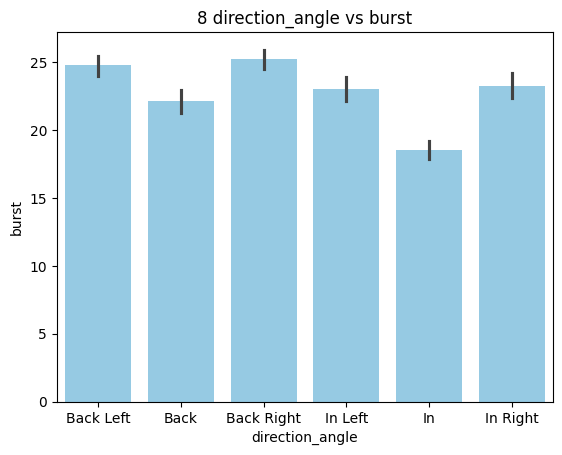

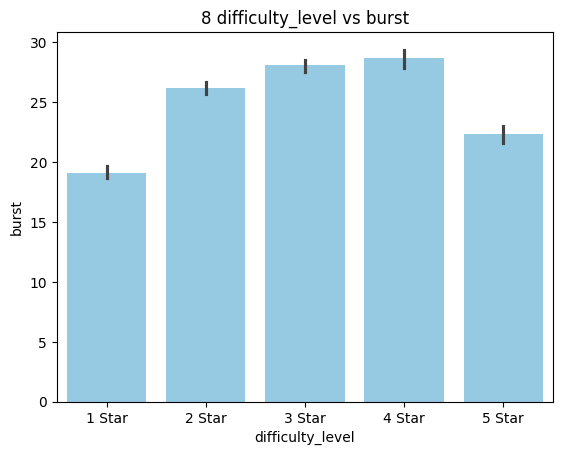

In [16]:
cf_jump_burst = jump_burst_df[jump_burst_df['player_attempt'] == 8].reset_index(drop=True).copy()

of_pos = 8

plt.figure()
sns.histplot(data=cf_jump_burst, x='burst', color='#89CFF0', stat='density', bins=25)
sns.kdeplot(data=cf_jump_burst, x='burst', color='#CC3433')
plt.title(f'{of_pos} Burst Distribution')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_burst, x='burst', y='opportunity_time', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_ot, p_ot = stats.pearsonr(cf_jump_burst['opportunity_time'], cf_jump_burst['burst'])
plt.title(f'{of_pos} opportunity_time vs burst (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_burst, x='burst', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dn, p_dn = stats.pearsonr(cf_jump_burst['distance_needed'], cf_jump_burst['burst'])
plt.title(f'{of_pos} distance_needed vs burst (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_burst, x='burst', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dw, p_dw = stats.pearsonr(cf_jump_burst['distance_to_wall'], cf_jump_burst['burst'])
plt.title(f'{of_pos} distance_to_wall vs burst (r = {round(r_dw, 2)})')
plt.show()

plt.figure()
ordered_directions = ['Back Left', 'Back', 'Back Right', 'In Left', 'In', 'In Right']
sns.barplot(data=cf_jump_burst, x='direction_angle', y='burst', order = ordered_directions, color='#89CFF0')
plt.title(f'{of_pos} direction_angle vs burst')
plt.show()

plt.figure()
ordered_levels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']
sns.barplot(data=cf_jump_burst, x='difficulty_level', y='burst', order = ordered_levels, color='#89CFF0')
plt.title(f'{of_pos} difficulty_level vs burst')
plt.show()

#### Modeling

In [430]:
## burst model for center fielder
burst_8_eNET = jump_model(jump_burst_df, 'burst', 8)
burst_8_eNET

(ElasticNet(alpha=0.01, l1_ratio=0.9), 5.523167069313238)

### Right Fielder

#### EDA

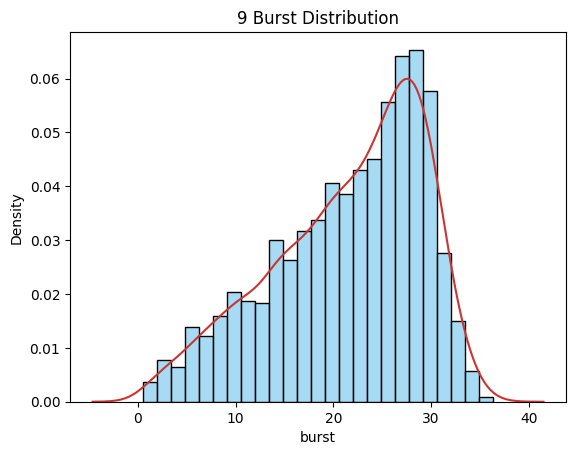

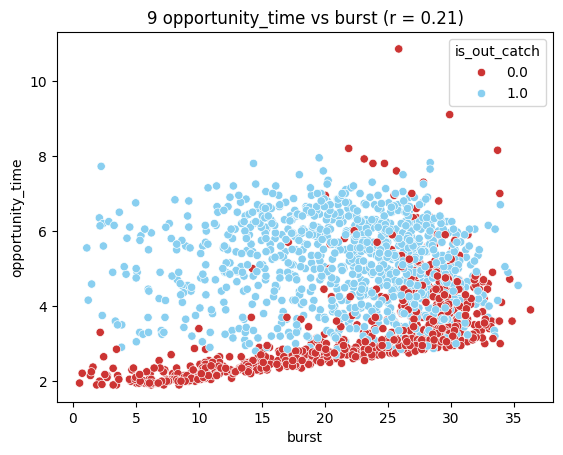

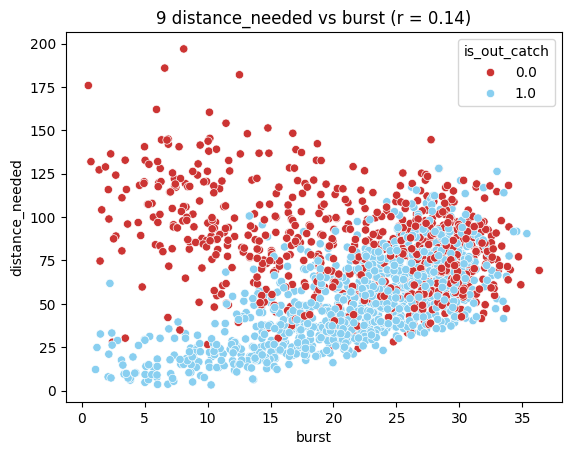

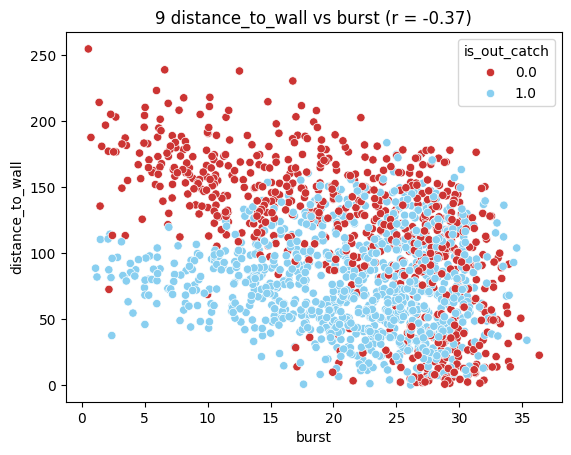

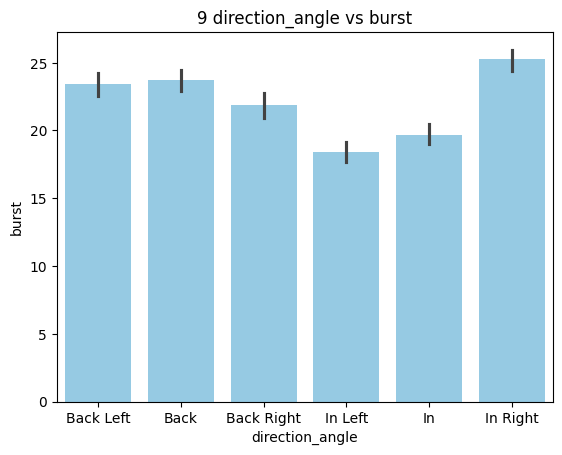

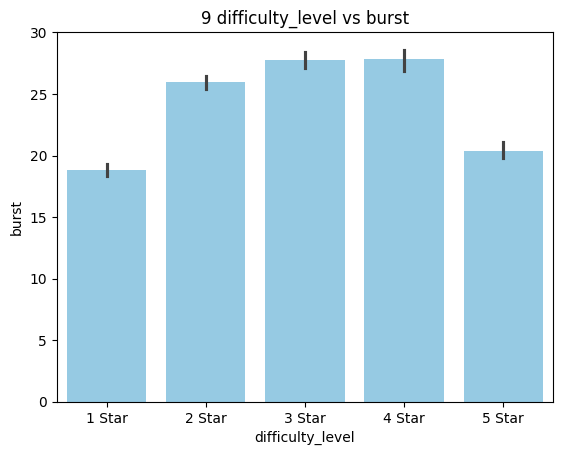

In [17]:
rf_jump_burst = jump_burst_df[jump_burst_df['player_attempt'] == 9].reset_index(drop=True).copy()

of_pos = 9

plt.figure()
sns.histplot(data=rf_jump_burst, x='burst', color='#89CFF0', stat='density', bins=25)
sns.kdeplot(data=rf_jump_burst, x='burst', color='#CC3433')
plt.title(f'{of_pos} Burst Distribution')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_burst, x='burst', y='opportunity_time', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_ot, p_ot = stats.pearsonr(rf_jump_burst['opportunity_time'], rf_jump_burst['burst'])
plt.title(f'{of_pos} opportunity_time vs burst (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_burst, x='burst', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dn, p_dn = stats.pearsonr(rf_jump_burst['distance_needed'], rf_jump_burst['burst'])
plt.title(f'{of_pos} distance_needed vs burst (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_burst, x='burst', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dw, p_dw = stats.pearsonr(rf_jump_burst['distance_to_wall'], rf_jump_burst['burst'])
plt.title(f'{of_pos} distance_to_wall vs burst (r = {round(r_dw, 2)})')
plt.show()

plt.figure()
ordered_directions = ['Back Left', 'Back', 'Back Right', 'In Left', 'In', 'In Right']
sns.barplot(data=rf_jump_burst, x='direction_angle', y='burst', order = ordered_directions, color='#89CFF0')
plt.title(f'{of_pos} direction_angle vs burst')
plt.show()

plt.figure()
ordered_levels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']
sns.barplot(data=rf_jump_burst, x='difficulty_level', y='burst', order = ordered_levels, color='#89CFF0')
plt.title(f'{of_pos} difficulty_level vs burst')
plt.show()

#### Modeling

In [431]:
## burst model for right fielder
burst_9_eNET = jump_model(jump_burst_df, 'burst', 9)
burst_9_eNET

(ElasticNet(alpha=0.01, l1_ratio=0.9), 5.86514724564042)

## Route Model

### Left Fielder

#### EDA

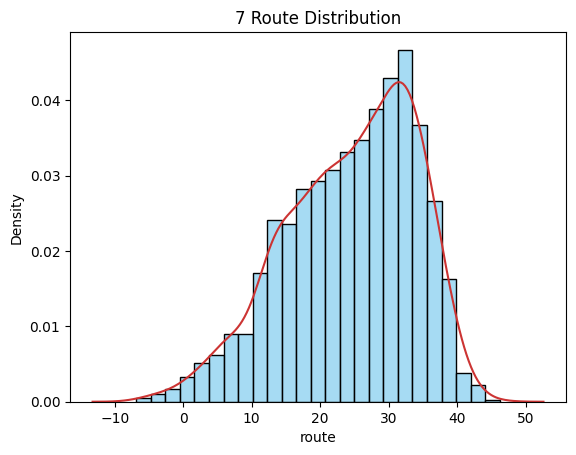

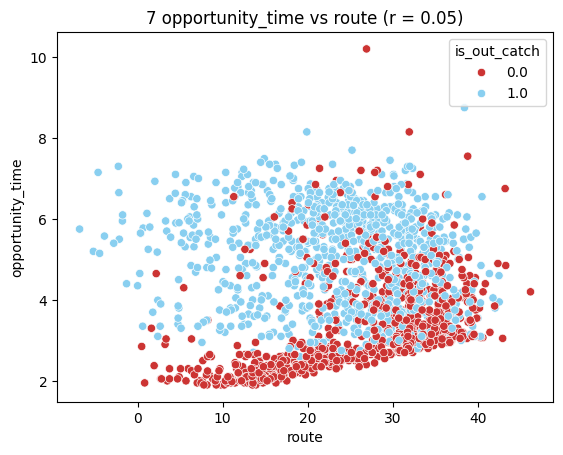

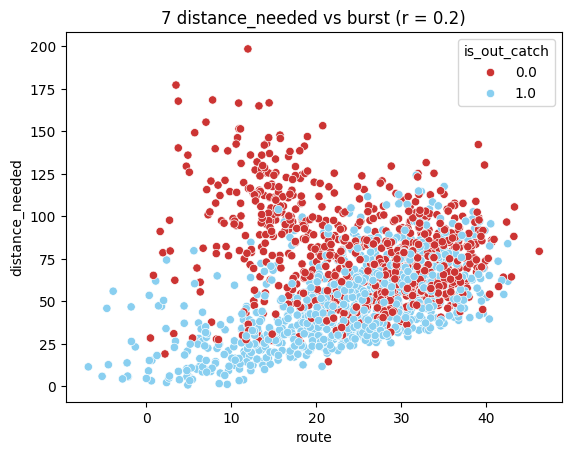

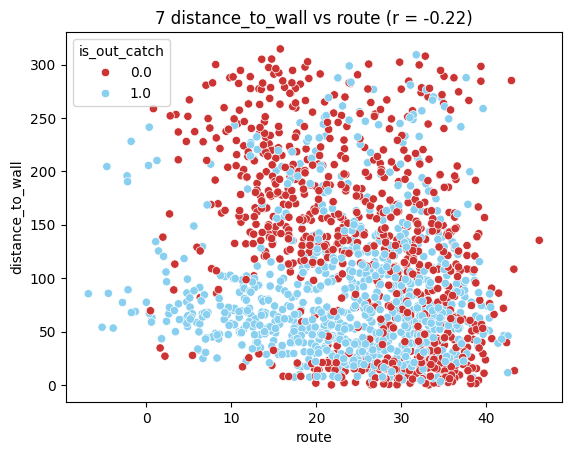

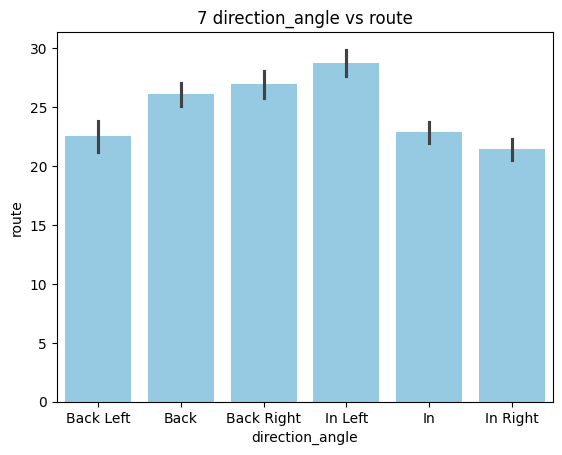

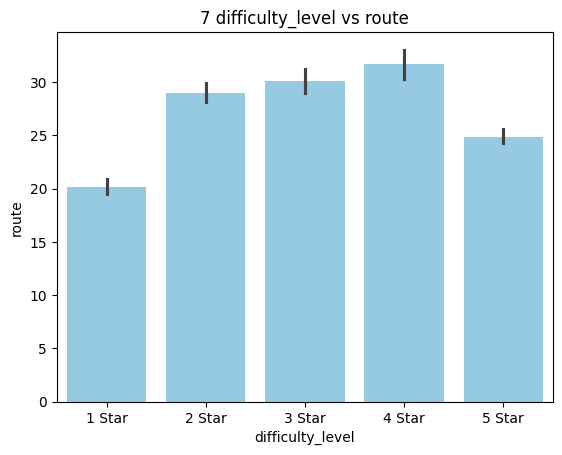

In [18]:
lf_jump_route = jump_route_df[jump_route_df['player_attempt'] == 7].reset_index(drop=True).copy()

of_pos = 7

plt.figure()
sns.histplot(data=lf_jump_route, x='route', color='#89CFF0', stat='density', bins=25)
sns.kdeplot(data=lf_jump_route, x='route', color='#CC3433')
plt.title(f'{of_pos} Route Distribution')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_route, x='route', y='opportunity_time', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_ot, p_ot = stats.pearsonr(lf_jump_route['opportunity_time'], lf_jump_route['route'])
plt.title(f'{of_pos} opportunity_time vs route (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_route, x='route', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dn, p_dn = stats.pearsonr(lf_jump_route['distance_needed'], lf_jump_route['route'])
plt.title(f'{of_pos} distance_needed vs burst (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_route, x='route', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dw, p_dw = stats.pearsonr(lf_jump_route['distance_to_wall'], lf_jump_route['route'])
plt.title(f'{of_pos} distance_to_wall vs route (r = {round(r_dw, 2)})')
plt.show()

plt.figure()
ordered_directions = ['Back Left', 'Back', 'Back Right', 'In Left', 'In', 'In Right']
sns.barplot(data=lf_jump_route, x='direction_angle', y='route', order = ordered_directions, color='#89CFF0')
plt.title(f'{of_pos} direction_angle vs route')
plt.show()

plt.figure()
ordered_levels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']
sns.barplot(data=lf_jump_route, x='difficulty_level', y='route', order = ordered_levels, color='#89CFF0')
plt.title(f'{of_pos} difficulty_level vs route')
plt.show()

#### Modeling

In [432]:
## route model for left fielder
route_7_eNET = jump_model(jump_route_df, 'route', 7)
route_7_eNET

(ElasticNet(alpha=0.01, l1_ratio=0.9), 7.740748826019055)

### Center Fielder

#### EDA

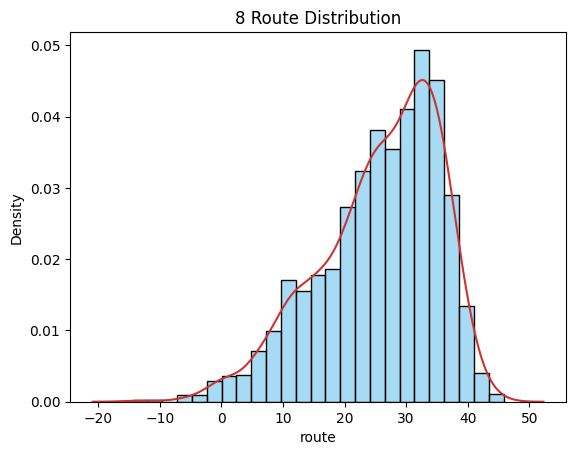

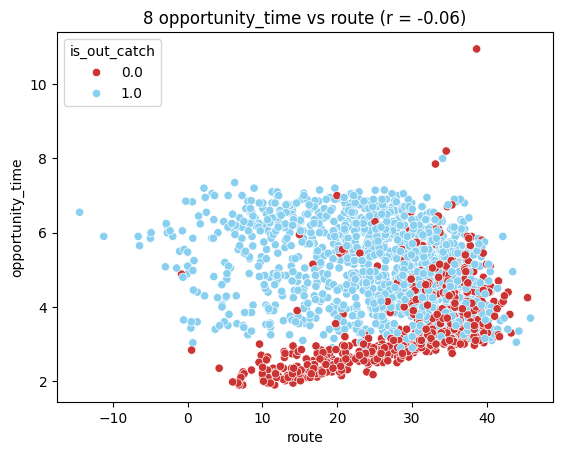

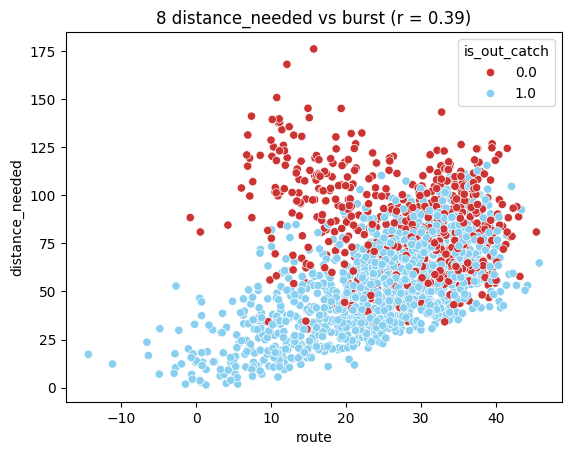

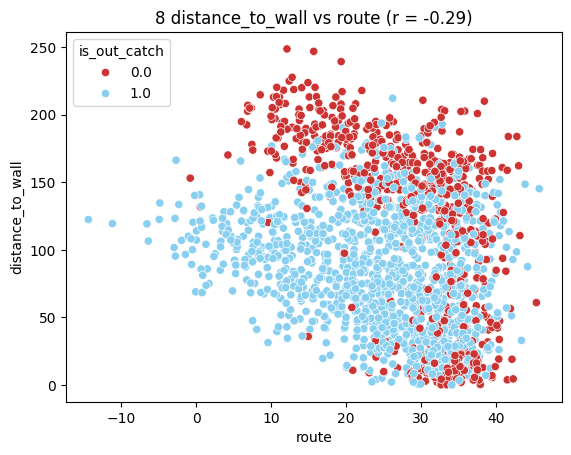

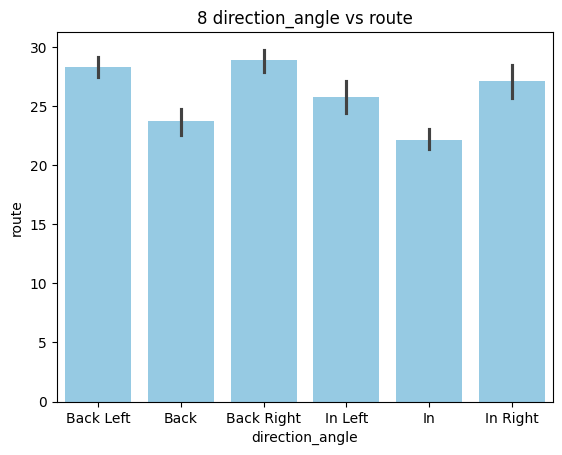

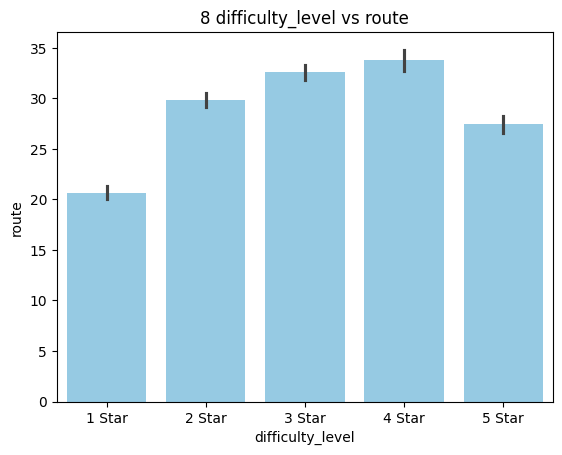

In [19]:
cf_jump_route = jump_route_df[jump_route_df['player_attempt'] == 8].reset_index(drop=True).copy()

of_pos = 8

plt.figure()
sns.histplot(data=cf_jump_route, x='route', color='#89CFF0', stat='density', bins=25)
sns.kdeplot(data=cf_jump_route, x='route', color='#CC3433')
plt.title(f'{of_pos} Route Distribution')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_route, x='route', y='opportunity_time', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_ot, p_ot = stats.pearsonr(cf_jump_route['opportunity_time'], cf_jump_route['route'])
plt.title(f'{of_pos} opportunity_time vs route (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_route, x='route', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dn, p_dn = stats.pearsonr(cf_jump_route['distance_needed'], cf_jump_route['route'])
plt.title(f'{of_pos} distance_needed vs burst (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_route, x='route', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dw, p_dw = stats.pearsonr(cf_jump_route['distance_to_wall'], cf_jump_route['route'])
plt.title(f'{of_pos} distance_to_wall vs route (r = {round(r_dw, 2)})')
plt.show()

plt.figure()
ordered_directions = ['Back Left', 'Back', 'Back Right', 'In Left', 'In', 'In Right']
sns.barplot(data=cf_jump_route, x='direction_angle', y='route', order = ordered_directions, color='#89CFF0')
plt.title(f'{of_pos} direction_angle vs route')
plt.show()

plt.figure()
ordered_levels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']
sns.barplot(data=cf_jump_route, x='difficulty_level', y='route', order = ordered_levels, color='#89CFF0')
plt.title(f'{of_pos} difficulty_level vs route')
plt.show()

#### Modeling

In [433]:
## route model for center fielder
route_8_eNET = jump_model(jump_route_df, 'route', 8)
route_8_eNET

(ElasticNet(alpha=0.01), 6.831137925165754)

### Right Fielder

#### EDA

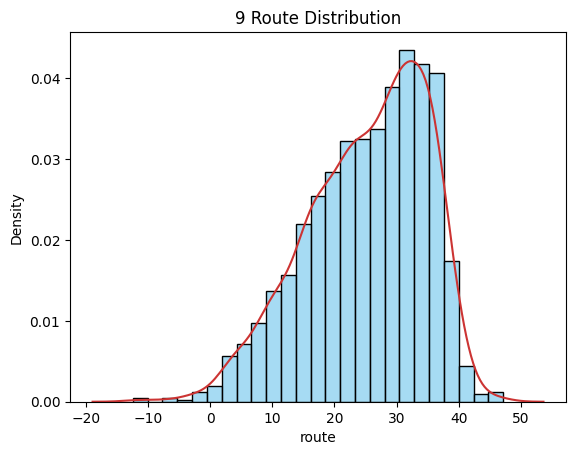

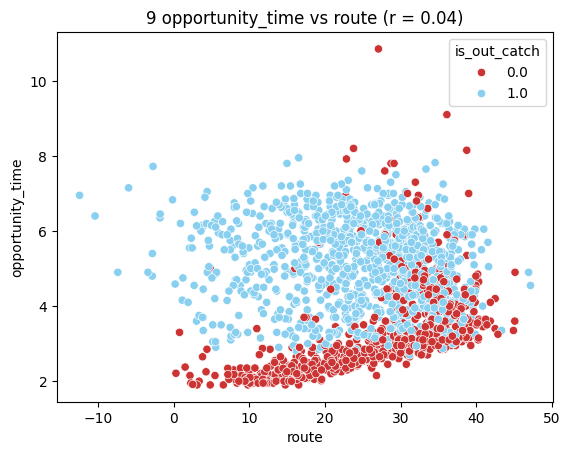

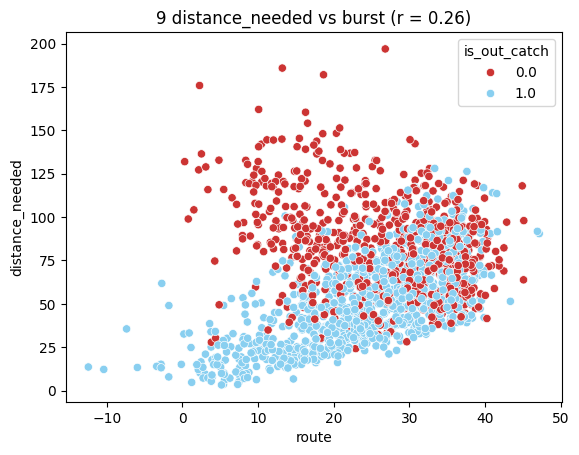

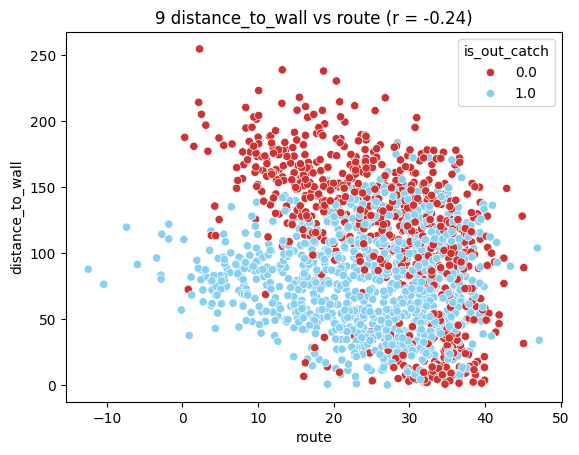

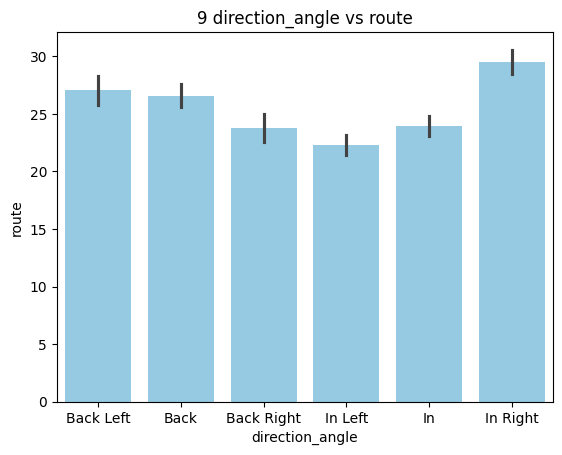

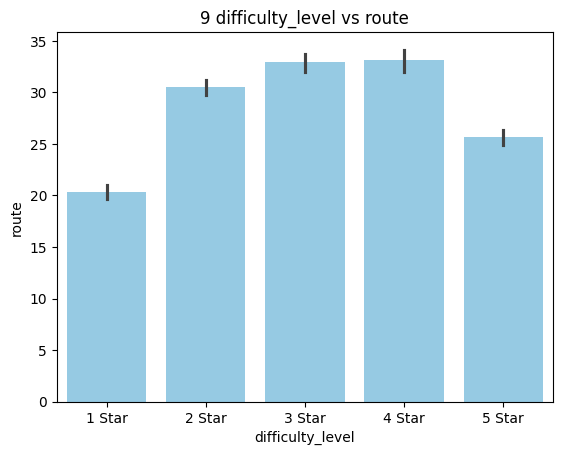

In [20]:
rf_jump_route = jump_route_df[jump_route_df['player_attempt'] == 9].reset_index(drop=True).copy()

of_pos = 9

plt.figure()
sns.histplot(data=rf_jump_route, x='route', color='#89CFF0', stat='density', bins=25)
sns.kdeplot(data=rf_jump_route, x='route', color='#CC3433')
plt.title(f'{of_pos} Route Distribution')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_route, x='route', y='opportunity_time', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_ot, p_ot = stats.pearsonr(rf_jump_route['opportunity_time'], rf_jump_route['route'])
plt.title(f'{of_pos} opportunity_time vs route (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_route, x='route', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dn, p_dn = stats.pearsonr(rf_jump_route['distance_needed'], rf_jump_route['route'])
plt.title(f'{of_pos} distance_needed vs burst (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_route, x='route', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
r_dw, p_dw = stats.pearsonr(rf_jump_route['distance_to_wall'], rf_jump_route['route'])
plt.title(f'{of_pos} distance_to_wall vs route (r = {round(r_dw, 2)})')
plt.show()

plt.figure()
ordered_directions = ['Back Left', 'Back', 'Back Right', 'In Left', 'In', 'In Right']
sns.barplot(data=rf_jump_route, x='direction_angle', y='route', order = ordered_directions, color='#89CFF0')
plt.title(f'{of_pos} direction_angle vs route')
plt.show()

plt.figure()
ordered_levels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']
sns.barplot(data=rf_jump_route, x='difficulty_level', y='route', order = ordered_levels, color='#89CFF0')
plt.title(f'{of_pos} difficulty_level vs route')
plt.show()

#### Modeling

In [434]:
## route model for right fielder
route_9_eNET = jump_model(jump_route_df, 'route', 9)
route_9_eNET

(ElasticNet(alpha=0.01), 7.683420725653876)

## Model Results

In [420]:
model_results_dict = {}
model_results_dict['reaction'] = {'reaction_7_model': reaction_7_eNET[0],
                                  'reaction_8_model': reaction_8_eNET[0],
                                  'reaction_9_model': reaction_9_eNET[0],
                                  'reaction_7_rmse': reaction_7_eNET[1],
                                  'reaction_8_rmse': reaction_8_eNET[1],
                                  'reaction_9_rmse': reaction_9_eNET[1]}
model_results_dict['burst'] = {'burst_7_model': burst_7_eNET[0],
                                  'burst_8_model': burst_8_eNET[0],
                                  'burst_9_model': burst_9_eNET[0],
                                  'burst_7_rmse': burst_7_eNET[1],
                                  'burst_8_rmse': burst_8_eNET[1],
                                  'burst_9_rmse': burst_9_eNET[1]}
model_results_dict['route'] = {'route_7_model': route_7_eNET[0],
                                  'route_8_model': route_8_eNET[0],
                                  'route_9_model': route_9_eNET[0],
                                  'route_7_rmse': route_7_eNET[1],
                                  'route_8_rmse': route_8_eNET[1],
                                  'route_9_rmse': route_9_eNET[1]}

In [421]:
model_results_dict

{'reaction': {'reaction_7_model': ElasticNet(alpha=0.01, l1_ratio=0.1),
  'reaction_8_model': ElasticNet(alpha=0.01, l1_ratio=0.1),
  'reaction_9_model': ElasticNet(alpha=0.01, l1_ratio=0.1),
  'reaction_7_rmse': 1.7379930375825743,
  'reaction_8_rmse': 1.68626514636911,
  'reaction_9_rmse': 1.8753695074126386},
 'burst': {'burst_7_model': ElasticNet(alpha=0.01, l1_ratio=0.1),
  'burst_8_model': ElasticNet(alpha=0.01, l1_ratio=0.9),
  'burst_9_model': ElasticNet(alpha=0.01, l1_ratio=0.9),
  'burst_7_rmse': 5.910551708975415,
  'burst_8_rmse': 5.523167069313238,
  'burst_9_rmse': 5.86514724564042},
 'route': {'route_7_model': ElasticNet(alpha=0.01, l1_ratio=0.9),
  'route_8_model': ElasticNet(alpha=0.01),
  'route_9_model': ElasticNet(alpha=0.01),
  'route_7_rmse': 7.740748826019055,
  'route_8_rmse': 6.831137925165754,
  'route_9_rmse': 7.683420725653876}}

In [23]:
std_dict

{'reaction': {'7': 2.3190926081332623,
  '8': 2.5495904142285175,
  '9': 2.1610054813733623},
 'burst': {'7': 7.5664118382054175,
  '8': 9.296900312561128,
  '9': 5.047896088741524},
 'route': {'7': 9.472422792260582,
  '8': 10.954600194953308,
  '9': 6.071471639029123}}

In [422]:
def apply_function(df: pd.DataFrame, component: str, pos: int):
    """
    

    Arguments: 
    """
    df = df.copy()
    # df = df[df['player_attempt'] == pos].reset_index(drop=True).copy()

    X = df[['game_str_id', f'{component}_{pos}', 'opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle', 'difficulty_level']].copy()
    X.loc[:, 'direction_cat_code'] = X['direction_angle'].astype('category').cat.codes
    X.loc[:, 'difficulty_cat_code'] = X['difficulty_level'].astype('category').cat.codes
    X_scaled = scaler.fit_transform(X[['opportunity_time', 'distance_needed', 'distance_to_wall']].values)
    X_params = np.hstack([X_scaled, X[['direction_cat_code', 'difficulty_cat_code']].values])

    model_pointer = model_results_dict[component][f'{component}_{pos}_model']

    ## creates the prediction for that game_str_id
    X.loc[:, f'expected_{component}_{pos}'] = model_pointer.predict(X_params).astype(float)

    return X[['game_str_id', f'expected_{component}_{pos}']]

In [435]:
## reaction dfs
reaction_7_df = apply_function(jump_df, 'reaction', 7)
reaction_8_df = apply_function(jump_df, 'reaction', 8)
reaction_9_df = apply_function(jump_df, 'reaction', 9)
merged_reaction_df = reaction_7_df.merge(reaction_8_df, how='left', on='game_str_id')
merged_reaction_df = merged_reaction_df.merge(reaction_9_df, how='left', on='game_str_id')

## burst dfs
burst_7_df = apply_function(jump_df, 'burst', 7)
burst_8_df = apply_function(jump_df, 'burst', 8)
burst_9_df = apply_function(jump_df, 'burst', 9)
merged_burst_df = burst_7_df.merge(burst_8_df, how='left', on='game_str_id')
merged_burst_df = merged_burst_df.merge(burst_9_df, how='left', on='game_str_id')

## route dfs
route_7_df = apply_function(jump_df, 'route', 7)
route_8_df = apply_function(jump_df, 'route', 8)
route_9_df = apply_function(jump_df, 'route', 9)
merged_route_df = route_7_df.merge(route_8_df, how='left', on='game_str_id')
merged_route_df = merged_route_df.merge(route_9_df, how='left', on='game_str_id')

expected_components_df = merged_reaction_df.merge(merged_burst_df, how='left', on='game_str_id')
expected_components_df = expected_components_df.merge(merged_route_df, how='left', on='game_str_id')

In [436]:
jump_df.merge(expected_components_df, how='left', on='game_str_id').to_csv('jump_data.csv')

In [22]:
std_dict = {}
std_dict['reaction'] = {'7': lf_jump_reaction['reaction_7'].std(),
                        '8': lf_jump_reaction['reaction_8'].std(),
                        '9': lf_jump_reaction['reaction_9'].std(),}
std_dict['burst'] = {'7': lf_jump_reaction['burst_7'].std(),
                        '8': lf_jump_reaction['burst_8'].std(),
                        '9': lf_jump_reaction['burst_9'].std(),}
std_dict['route'] = {'7': lf_jump_reaction['route_7'].std(),
                        '8': lf_jump_reaction['route_8'].std(),
                        '9': lf_jump_reaction['route_9'].std(),}
std_dict

{'reaction': {'7': 2.3190926081332623,
  '8': 2.5495904142285175,
  '9': 2.1610054813733623},
 'burst': {'7': 7.5664118382054175,
  '8': 9.296900312561128,
  '9': 5.047896088741524},
 'route': {'7': 9.472422792260582,
  '8': 10.954600194953308,
  '9': 6.071471639029123}}